╭───────────────────────────────────────────── PyCHARMM environment ──────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Field                  ┃ Value                                                                              ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩ │
│ │ CGENFF RTF             │ /home/ericb/mmml/mmml/data/charmm/top_all36_cgenff.rtf                             │ │
│ │ CGENFF PRM             │ /home/ericb/mmml/mmml/data/charmm/par_all36_cgenff.prm                             │ │
│ │ CHARMM_HOME            │ /home/ericb/mmml/setup/charmm                                                      │ │
│ │ CHARMM_LIB_DIR         │ /home/ericb/mmml/setup/charmm                                                      │ │
│ └────────────────────────┴────────────────────────────────────────────────────────────────────────────────────┘ │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

CHARMM_HOME:  /home/ericb/mmml/setup/charmm
CHARMM_LIB_DIR:  /home/ericb/mmml/setup/charmm
 TITLE> *  --------------------------------------------------------------------------  *
 TITLE> *          CGENFF: TOPOLOGY FOR THE CHARMM GENERAL FORCE FIELD V. 4.6          *
 TITLE> *                    FOR SMALL MOLECULE DRUG DESIGN                            *
 TITLE> *  --------------------------------------------------------------------------  *
 TITLE> *
 TITLE> * TRIA BACKBONE CMAP (ALANINE GRID FROM PROTEIN PRM, CGENFF TYPES)
 TITLE> * REGENERATE: ./SCRIPTS/MMML-CHARMM-MPIRUN.SH PYTHON SCRIPTS/EXPORT_TRIALANINE_CGENFF_RTF.PY
 TITLE> CMAP
 PARMIO> NONBOND, HBOND lists and IMAGE atoms cleared.
 TITLE> * TRIALANINE — ACE–ALA×3–CT3 CAPPED TRI-ALANINE (CGENFF ATOM TYPES)
 TITLE> * REGENERATE: ./SCRIPTS/MMML-CHARMM-MPIRUN.SH PYTHON SCRIPTS/EXPORT_TRIALANINE_CGENFF_RTF.PY
 TITLE>  
          RESI TRIA      0.00

      ***** LEVEL  1 WARNING FROM <BILDC> *****
      ***** BILDC called with a n

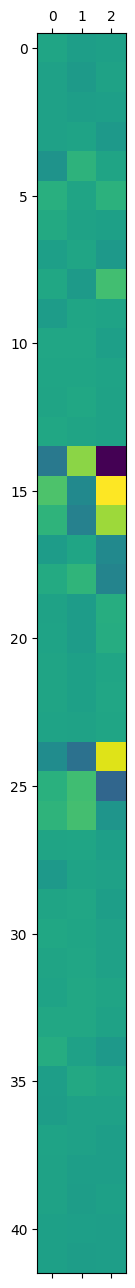

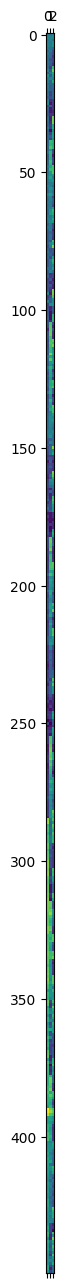

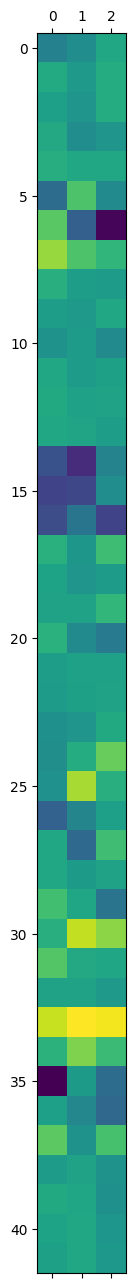

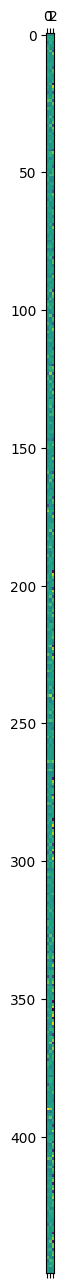

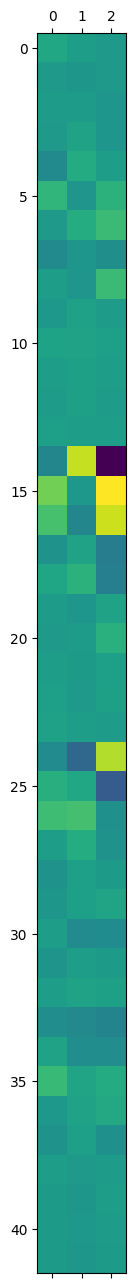

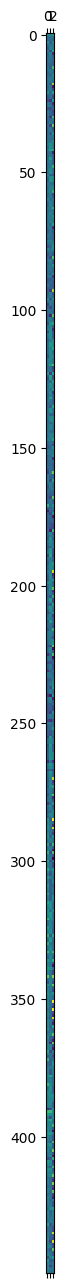

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.numpy.array(1, dtype=int)

import mmml
import ase
import numpy as np

from mmml.interfaces.pycharmmInterface.mm_system_energy import (
    CharmmNbondSettings,
    mm_system_energy_and_forces,
)

from pathlib import Path
from mmml.interfaces.pycharmmInterface.import_pycharmm import ensure_pycharmm_loaded
ensure_pycharmm_loaded()
from mmml.interfaces.pycharmmInterface.trialanine_water_box import build_trialanine_water_box_in_charmm
box = build_trialanine_water_box_in_charmm(n_waters=150, box_side_A=28.0, seed=11, workdir=Path('/tmp/tria_box'))
print(len(box.positions), box.psf_path)# ase.Atoms()
positions = box.positions
from mmml.interfaces.pycharmmInterface.import_pycharmm import CGENFF_PRM
prm = CGENFF_PRM
from mmml.interfaces.pycharmmInterface.import_pycharmm import pycharmm_loud
import pycharmm.lingo as lingo

pycharmm_loud()

from mmml.interfaces.pycharmmInterface.cgenff_bonded_reference import (
    charmm_bonded_forces_kcalmol_A,
    charmm_nonbonded_energy_components_kcalmol,
    run_charmm_nonbonded_ener_force,
    set_charmm_positions,
    setup_nonbonded_only_charmm,
)
from mmml.interfaces.pycharmmInterface.mm_system_energy import (
    load_nonbonded_system_from_charmm,
    nonbonded_energy_and_forces,
)


pos = np.asarray(positions, dtype=np.float64)
pos = np.random.uniform(-.1, .1, pos.shape) + pos
set_charmm_positions(pos)

print("pos", pos)

setup_nonbonded_only_charmm()
print("setup_nonbonded_only_charmm")
# perform charmm minimization
lingo.charmm_script("""CONStraint DROPlet FORC 0.0001 EXPO 4 ! [FORCe real] [EXPOnent integer] [NOMAss]""")
from mmml.interfaces.pycharmmInterface.charmm_levels import run_charmm_script_loud
run_charmm_script_loud("""
    MINI SD 10000
""")
# print("run_charmm_script_loud")
# lingo.charmm_script("""CONStraint DROPlet !""")
from mmml.interfaces.pycharmmInterface.charmm_levels import run_charmm_script_loud
run_charmm_script_loud("""
    MINI SD 10000
""")
print("run_charmm_script_loud")
# lingo.charmm_script("""CONStraint DROPlet FORC 0.01 EXPO 1 ! [FORCe real] [EXPOnent integer] [NOMAss]""")
from mmml.interfaces.pycharmmInterface.import_pycharmm import coor
pos = coor.get_positions()[["x", "y", "z"]].to_numpy(dtype=float)
print("pos", pos)
from mmml.interfaces.pycharmmInterface.utils import get_Z_from_psf
z = get_Z_from_psf()
print("z", z)
atoms = ase.Atoms(z, pos)
print("atoms", atoms)
# save atoms to pdb file
atoms.write("atoms.pdb")

run_charmm_nonbonded_ener_force(silent=False)
charmm_terms = charmm_nonbonded_energy_components_kcalmol()
charmm_forces = charmm_bonded_forces_kcalmol_A()

# print(charmm_terms)
psf_path = box.psf_path
prm_path = CGENFF_PRM
cell = box.cell
from mmml.interfaces.pycharmmInterface.charmm_jax_energy_benchmark import _nbond_settings_from_cutoffs
nb_settings = _nbond_settings_from_cutoffs(box.nbond_cutoffs)
nbond_data = load_nonbonded_system_from_charmm(psf_path, prm_path)
jax_terms_raw, jax_forces = nonbonded_energy_and_forces(
    pos,
    nbond_data,
    cell,
    nb_settings,
)
jax_terms = {k: float(v) for k, v in jax_terms_raw.items()}
jax_forces_np = np.asarray(jax_forces, dtype=np.float64)

print(jax_terms)
# print(jax_forces_np)
print(charmm_terms)
# print(charmm_forces)

import matplotlib.pyplot as plt
plt.matshow(charmm_forces[:42])
plt.matshow(charmm_forces[42:])
plt.matshow(jax_forces[:42])
plt.matshow(jax_forces[42:])
plt.matshow(charmm_forces[:42] - jax_forces[:42])
plt.matshow(charmm_forces[42:] - jax_forces[42:])

In [2]:

lingo.charmm_script(
    """
DEFINE PHSSOLU SELE RESNAME TRIA .AND. .NOT. HYDROGEN END
DEFINE PHSWAT  SELE RESNAME TIP3 .AND. TYPE OH2 END

SHOW NSEL SELE PHSSOLU END
SHOW NSEL SELE PHSWAT END
"""
)

 SELRPN>     20 atoms have been selected out of    492
 SELRPN>    150 atoms have been selected out of    492


True

In [3]:
import pycharmm.psf as psf

print(set(psf.get_res()))
print(set(psf.get_atype()))

{'TRIA', 'TIP3'}
{'CA1', 'CAY', 'CB2', 'HT1', 'H2', 'HY1', 'N3', 'O3', 'C3', 'HB23', 'OH2', 'C1', 'CA3', 'HT2', 'CB1', 'N1', 'HB11', 'O1', 'HNT', 'HB31', 'HA2', 'CAT', 'HY3', 'HB12', 'NT', 'HB21', 'HY2', 'N2', 'HA1', 'C2', 'HT3', 'HN3', 'CY', 'HN2', 'HB32', 'O2', 'HB33', 'OY', 'HA3', 'HB22', 'CB3', 'H1', 'HN1', 'HB13', 'CA2'}


In [11]:
from mmml.interfaces.pycharmmInterface import import_pycharmm
import_pycharmm.view_pycharmm_state()

In [12]:
lingo.charmm_script("""ENERGY
""")


 SELECTED IMAGES ATOMS BEING CENTERED ABOUT  0.000000  0.000000  0.000000

 <MKIMAT2>: updating the image atom lists and remapping
 Transformation   Atoms  Groups  Residues  Min-Distance
    1  N1Z0N1R1 has       0       0       0       19.42
    2  Z0N1N1R1 has       0       0       0       19.77
    3  Z0Z0N1R1 has       3       1       1       12.39
    4  Z0P1N1R1 has       0       0       0       20.34
    5  N1Z0Z0R1 has      24       8       8       11.88
    6  Z0N1Z0R1 has       6       2       2       12.54
    8  N1Z0P1R1 has       0       0       0       19.79
 Total of  525 atoms and  167 groups and  162 residues were included

 <MAKGRP> found      0 image group exclusions.

 NONBOND OPTION FLAGS: 
     ELEC     VDW      ATOMs    CDIElec  FSWItch  VATOm    VFSWIt  
     BYGRoup  NOEXtnd  NOEWald 
 CUTNB  = 13.000 CTEXNB =999.000 CTONNB =  9.000 CTOFNB = 12.278
 CGONNB =  0.000 CGOFNB = 10.000
 WMIN   =  1.500 WRNMXD =  0.500 E14FAC =  1.000 EPS    =  1.000
 NBXMOD =      

True

In [13]:
lingo.charmm_script("""CONStraint DROPlet FORC !1.0 ! [FORCe real] [EXPOnent integer] [NOMAss]""")

 WARNING FROM DECODF - COULD NOT CONVERT STRING
 !1.0

      ***** LEVEL  0 WARNING FROM <DECODF> *****
      ***** Could not convert string
      ******************************************
      BOMLEV ( -2) IS NOT REACHED. WRNLEV IS  9

ZERO WILL BE RETURNED.
 DROPLET CONSTRAINTS REMOVED


True

In [14]:
# print("run_charmm_script_loud")
# lingo.charmm_script("""CONStraint DROPlet !""")
from mmml.interfaces.pycharmmInterface.charmm_levels import run_charmm_script_loud
run_charmm_script_loud("""
    MINI SD 1000
""")
lingo.charmm_script("MINI SD 1000")
print("run_charmm_script_loud")
# lingo.charmm_script("""CONStraint DROPlet FORC 0.01 EXPO 1 ! [FORCe real] [EXPOnent integer] [NOMAss]""")
from mmml.interfaces.pycharmmInterface.import_pycharmm import coor
pos = coor.get_positions()[["x", "y", "z"]].to_numpy(dtype=float)
print("pos", pos)
from mmml.interfaces.pycharmmInterface.utils import get_Z_from_psf
z = get_Z_from_psf()
print("z", z)
atoms = ase.Atoms(z, pos)
print("atoms", atoms)
# save atoms to pdb file
atoms.write("atoms.pdb")


 SELECTED IMAGES ATOMS BEING CENTERED ABOUT  0.000000  0.000000  0.000000

 <MKIMAT2>: updating the image atom lists and remapping
 Transformation   Atoms  Groups  Residues  Min-Distance
    1  N1Z0N1R1 has       0       0       0       19.15
    2  Z0N1N1R1 has       0       0       0       19.38
    3  Z0Z0N1R1 has       9       3       3       12.00
    4  Z0P1N1R1 has       0       0       0       19.90
    5  N1Z0Z0R1 has      24       8       8       11.65
    6  Z0N1Z0R1 has      15       5       5       12.06
    8  N1Z0P1R1 has       0       0       0       19.32
 Total of  540 atoms and  172 groups and  167 residues were included

 <MAKGRP> found      0 image group exclusions.

 NONBOND OPTION FLAGS: 
     ELEC     VDW      ATOMs    CDIElec  FSWItch  VATOm    VFSWIt  
     BYGRoup  NOEXtnd  NOEWald 
 CUTNB  = 13.000 CTEXNB =999.000 CTONNB =  9.000 CTOFNB = 12.278
 CGONNB =  0.000 CGOFNB = 10.000
 WMIN   =  1.500 WRNMXD =  0.500 E14FAC =  1.000 EPS    =  1.000
 NBXMOD =      

In [15]:
molecule_id = np.empty(len(atoms), dtype=np.int32)

# Trialanine
molecule_id[:42] = 0

# 50 water molecules
for mol_id, start in enumerate(
    range(42, len(atoms), 3),
    start=1,
):
    molecule_id[start:start + 3] = mol_id

assert np.all(molecule_id[:42] == 0)

for start in range(42, len(atoms), 3):
    assert len(set(molecule_id[start:start + 3])) == 1

# assert molecule_id.max() == 50

In [16]:
jax_terms_raw, jax_forces = nonbonded_energy_and_forces(
    pos,
    nbond_data,
    cell,
    nb_settings,
    molecule_id=molecule_id,
)

In [17]:
full_terms, _ = nonbonded_energy_and_forces(
    pos,
    nbond_data,
    cell,
    nb_settings,
)

inter_terms, _ = nonbonded_energy_and_forces(
    pos,
    nbond_data,
    cell,
    nb_settings,
    molecule_id=molecule_id,
)

In [18]:
print("full:", {k: float(v) for k, v in full_terms.items()})
print("inter:", {k: float(v) for k, v in inter_terms.items()})

full: {'vdw': 384.0921346994329, 'elec': -1908.9494965831557, 'total': -1524.8573618837227}
inter: {'vdw': 387.93103062603575, 'elec': -1912.9419134022407, 'total': -1525.010882776205}


In [19]:
charmm_terms

{'vdw': 60.58473164109281,
 'elec': -581.5902358114022,
 'total': -521.0055041703093}

In [20]:
jax_terms_raw

{'vdw': Array(387.93103063, dtype=float64),
 'elec': Array(-1912.9419134, dtype=float64),
 'total': Array(-1525.01088278, dtype=float64)}

In [21]:
nb_settings

CharmmNbondSettings(cutnb=13.0, ctonnb=9.0, ctofnb=12.277777777777777, eps=1.0, e14fac=1.0, vdw14fac=0.0, elec_switch='fswitch', vdw_switch='vfswitch')

In [22]:
from mmml.interfaces.pycharmmInterface import import_pycharmm
import_pycharmm.view_pycharmm_state()

In [23]:
CKPT_PATH = "/home/ericb/mmml/artifacts/md_embedding/aaa_docs/checkpoints/params_aaa_long_2026-07-04_22-30-27.json"

In [24]:
from mmml.interfaces.calculators.simple_inference import create_calculator_from_checkpoint

In [25]:
calc = create_calculator_from_checkpoint(CKPT_PATH)

✓ Loaded checkpoint from /home/ericb/mmml/artifacts/md_embedding/aaa_docs/checkpoints/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']


In [26]:
calc

<mmml.models.physnetjax.physnetjax.calc.helper_mlp.get_ase_calc.<locals>.MessagePassingCalculator at 0x7f7d5d0138c0>

In [27]:
atoms.get_atomic_numbers()

array([6, 1, 1, 1, 6, 8, 7, 1, 6, 1, 6, 1, 1, 1, 6, 8, 7, 1, 6, 1, 6, 1,
       1, 1, 6, 8, 7, 1, 6, 1, 6, 1, 1, 1, 6, 8, 7, 1, 6, 1, 1, 1, 8, 1,
       1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1,
       8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8,
       1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1,
       1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1,
       8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8,
       1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1,
       1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1,
       8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8,
       1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1,
       1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1,
       8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8,
       1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8, 1, 1, 8,

In [28]:
prot = atoms[:42]
prot.get_atomic_numbers()
_pos = prot.get_positions()
prot.set_positions(_pos - _pos.T.mean(axis=-1))

In [29]:
water = atoms[42:]
water.get_atomic_numbers()
_pos = water.get_positions()
# water.set_positions(_pos - _pos.T.mean(axis=-1))

In [30]:
ase.visualize.view(prot, viewer="x3d")

In [31]:
ase.visualize.view(water, viewer="x3d")

In [32]:
ase.visualize.view(water + prot, viewer="x3d")

In [33]:
prot_water = prot + water

In [34]:
prot.calc = calc
water.calc = calc
prot_water.calc = calc

In [35]:
prot.get_potential_energy(), water.get_potential_energy(), prot_water.get_potential_energy()

(Array(-161.65481985, dtype=float64),
 Array(-1662.86564958, dtype=float64),
 Array(-1817.60856426, dtype=float64))

In [36]:
prot.get_forces()

array([[ 0.14224737, -0.1461193 , -0.95123097],
       [ 0.63208153, -0.08040031, -0.25308476],
       [-0.67843894,  0.87938818,  0.71378572],
       [ 0.02253136, -1.11278875,  0.89645015],
       [-0.72811218,  0.25608619, -0.44574229],
       [ 0.4229319 ,  0.86331592, -0.12682732],
       [-0.14154199, -1.64470419, -0.067084  ],
       [ 0.0469979 ,  0.12251684,  0.7280775 ],
       [-0.69579314, -1.76004695, -1.69365699],
       [ 1.07121546, -0.04861468,  0.42300945],
       [ 0.75313199, -0.24964778, -0.32192576],
       [-0.37743071,  0.3243373 , -0.4430307 ],
       [-0.20041229,  0.11955616,  0.55623465],
       [ 0.45689865,  0.71219672,  0.05128068],
       [ 1.08099861,  3.12470778,  0.1128916 ],
       [ 0.6603773 , -0.88942337,  0.81282353],
       [-1.16795363, -0.76220791,  0.12038726],
       [-0.26245208, -0.30110832, -0.89884738],
       [-2.5526135 , -0.56404092,  0.60943225],
       [ 0.20036202,  0.4150952 , -0.52791838],
       [-0.73132479, -0.03411481,  0.415

In [37]:
from ase.optimize import QuasiNewton

# 3. Attach to optimizer (QuasiNewton is an alias for BFGSLineSearch)
dyn = QuasiNewton(prot, trajectory='prot_min.traj')
# 4. Run minimization until max force on any atom < 0.05 eV/Å
dyn.run(fmax=0.3)


                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 21:26:08     -161.654820       5.0340


/home/ericb/mmml/.venv/lib/python3.13/site-packages/ase/io/trajectory.py:213: UserWarning: Skipping "output" info.
  warnings.warn(f'Skipping "{key}" info.')


BFGSLineSearch:    1[  2] 21:26:09     -162.813530       2.5505
BFGSLineSearch:    2[  4] 21:26:09     -163.263725       1.4976
BFGSLineSearch:    3[  6] 21:26:09     -163.453308       1.5717
BFGSLineSearch:    4[  8] 21:26:09     -163.600290       1.1851
BFGSLineSearch:    5[ 10] 21:26:09     -163.698445       1.0452
BFGSLineSearch:    6[ 12] 21:26:09     -163.764041       0.6747
BFGSLineSearch:    7[ 14] 21:26:09     -163.813782       0.5605
BFGSLineSearch:    8[ 16] 21:26:09     -163.842516       0.5383
BFGSLineSearch:    9[ 18] 21:26:09     -163.908451       1.0360
BFGSLineSearch:   10[ 20] 21:26:09     -163.952671       0.8277
BFGSLineSearch:   11[ 22] 21:26:09     -164.007206       0.8754
BFGSLineSearch:   12[ 24] 21:26:09     -164.073034       0.7500
BFGSLineSearch:   13[ 26] 21:26:09     -164.113847       0.6327
BFGSLineSearch:   14[ 28] 21:26:09     -164.161087       0.6610
BFGSLineSearch:   15[ 30] 21:26:09     -164.212414       0.5691
BFGSLineSearch:   16[ 32] 21:26:09     -

np.True_

In [38]:
ase.visualize.view(prot, viewer="x3d")

In [39]:
# 3. Attach to optimizer (QuasiNewton is an alias for BFGSLineSearch)
dyn = QuasiNewton(water, trajectory='water_min.traj')
# 4. Run minimization until max force on any atom < 0.05 eV/Å
dyn.run(fmax=5)
ase.visualize.view(water, viewer="x3d")

                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 21:26:09    -1662.865650       5.9070
BFGSLineSearch:    1[  2] 21:26:10    -1701.006808      22.8094
BFGSLineSearch:    2[  3] 21:26:10    -1718.847658      17.0607
BFGSLineSearch:    3[  4] 21:26:10    -1743.704307      17.1992
BFGSLineSearch:    4[  5] 21:26:10    -1762.371474      18.6039
BFGSLineSearch:    5[  6] 21:26:10    -1791.407164      26.4660
BFGSLineSearch:    6[  7] 21:26:10    -1810.463722      18.5435
BFGSLineSearch:    7[  9] 21:26:11    -1855.778191      23.9397
BFGSLineSearch:    8[ 10] 21:26:11    -1893.003047      23.7762
BFGSLineSearch:    9[ 11] 21:26:11    -1936.015508      21.9512
BFGSLineSearch:   10[ 12] 21:26:11    -1999.297459      21.5785
BFGSLineSearch:   11[ 13] 21:26:11    -2047.845308      31.8751
BFGSLineSearch:   12[ 14] 21:26:12    -2107.846758      22.2966
BFGSLineSearch:   13[ 15] 21:26:12    -2170.048131      17.9986
BFGSLineSearch:   14[ 16] 21:26:12    -

KeyboardInterrupt: 

In [40]:
# prot_water = prot + water 
# prot_water.calc = calc

In [41]:
# 3. Attach to optimizer (QuasiNewton is an alias for BFGSLineSearch)
dyn = QuasiNewton(prot_water, trajectory='prot_water_min.traj')
# 4. Run minimization until max force on any atom < 0.05 eV/Å
dyn.run(fmax=3)


                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 21:26:49    -1817.608564      63.3436
BFGSLineSearch:    1[  2] 21:26:49    -1903.979445      36.9606
BFGSLineSearch:    2[  4] 21:26:49    -2026.678903      37.2373
BFGSLineSearch:    3[  5] 21:26:50    -2124.129800      39.2280
BFGSLineSearch:    4[  6] 21:26:50    -2193.513542      34.6827
BFGSLineSearch:    5[  7] 21:26:50    -2263.096714      48.2998
BFGSLineSearch:    6[  8] 21:26:50    -2309.585057      65.1751
BFGSLineSearch:    7[  9] 21:26:50    -2367.526643      62.1889
BFGSLineSearch:    8[ 10] 21:26:50    -2402.252631      70.0350
BFGSLineSearch:    9[ 11] 21:26:51    -2460.512188      52.2856
BFGSLineSearch:   10[ 12] 21:26:51    -2524.961001      64.1445
BFGSLineSearch:   11[ 13] 21:26:51    -2577.479817      67.8224
BFGSLineSearch:   12[ 14] 21:26:51    -2632.272737      73.1897
BFGSLineSearch:   13[ 15] 21:26:51    -2680.842163     114.7797
BFGSLineSearch:   14[ 16] 21:26:52    -

KeyboardInterrupt: 

In [42]:
ase.visualize.view(prot_water, viewer="x3d")

In [43]:
z = get_Z_from_psf()


In [44]:
# pos = prot_water.get_positions()

# set_charmm_positions(pos)

print("pos", pos)

setup_nonbonded_only_charmm()
print("setup_nonbonded_only_charmm")
# perform charmm minimization
from mmml.interfaces.pycharmmInterface.charmm_levels import run_charmm_script_loud
run_charmm_script_loud("""
    MINI SD 10000
    MINI ABNR 10000
""")
print("run_charmm_script_loud")
from mmml.interfaces.pycharmmInterface.import_pycharmm import coor
pos = coor.get_positions()[["x", "y", "z"]].to_numpy(dtype=float)
print("pos", pos)
from mmml.interfaces.pycharmmInterface.utils import get_Z_from_psf
z = get_Z_from_psf()
print("z", z)
atoms = ase.Atoms(z, pos)
print("atoms", atoms)

# save atoms to pdb file
atoms.write("atoms.pdb")

pos [[-2.2952894  -5.61440131 -8.16139707]
 [-3.38954011 -5.75435254 -8.06522472]
 [-1.86079402 -6.4414416  -8.75687194]
 ...
 [-3.10151996  5.73216724  0.38802474]
 [-3.1414027   5.29118515 -0.48545996]
 [-3.99024373  5.51704259  0.71050562]]
setup_nonbonded_only_charmm
run_charmm_script_loud
pos [[-2.25074762 -5.77921421 -8.53502842]
 [-3.35478016 -5.6825104  -8.4786048 ]
 [-1.98214129 -6.71111712 -9.07546239]
 ...
 [-3.18757164  5.94448031  0.16977563]
 [-3.01718148  5.52533774 -0.70037213]
 [-4.15907153  5.87195119  0.2259717 ]]
z [np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.

In [45]:
from mmml.interfaces.pycharmmInterface import import_pycharmm
import_pycharmm.view_pycharmm_state()

In [46]:
box.nbond_cutoffs

PbcNbondCutoffs(cubic_box_side_A=28.0, cutnb=13.0, cutim=13.0, ctonnb=9.0, ctofnb=12.277777777777777, ctexnb=13.0)

In [47]:
from mmml.interfaces.pycharmmInterface.import_pycharmm import coor
pos = coor.get_positions()[["x", "y", "z"]].to_numpy(dtype=float)
print("pos", pos)
from mmml.interfaces.pycharmmInterface.utils import get_Z_from_psf
z = get_Z_from_psf()
print("z", z)
atoms = ase.Atoms(z, pos)
print("atoms", atoms)

# save atoms to pdb file
atoms.write("atoms.pdb")

run_charmm_nonbonded_ener_force(silent=False)
charmm_terms = charmm_nonbonded_energy_components_kcalmol()
charmm_forces = charmm_bonded_forces_kcalmol_A()

# print(charmm_terms)
psf_path = box.psf_path
prm_path = CGENFF_PRM
cell = box.cell
from mmml.interfaces.pycharmmInterface.charmm_jax_energy_benchmark import _nbond_settings_from_cutoffs
nb_settings = _nbond_settings_from_cutoffs(box.nbond_cutoffs)
nbond_data = load_nonbonded_system_from_charmm(psf_path, prm_path)
jax_terms_raw, jax_forces = nonbonded_energy_and_forces(
    pos,
    nbond_data,
    cell,
    nb_settings,
        molecule_id=molecule_id,
)
jax_terms = {k: float(v) for k, v in jax_terms_raw.items()}
jax_forces_np = np.asarray(jax_forces, dtype=np.float64)

print(jax_terms)
# print(jax_forces_np)
print(charmm_terms)
# print(charmm_forces)

pos [[-2.25074762 -5.77921421 -8.53502842]
 [-3.35478016 -5.6825104  -8.4786048 ]
 [-1.98214129 -6.71111712 -9.07546239]
 ...
 [-3.18757164  5.94448031  0.16977563]
 [-3.01718148  5.52533774 -0.70037213]
 [-4.15907153  5.87195119  0.2259717 ]]
z [np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(6), np.int64(8), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(1), np.int64(1), np.int64(8), np.int64(1), np.int64(1), np.int64(8), np.int64(1), np.int64(1), np.int64(8), np.int64(1), np.int64(1), np.int64(8), np.int64(1), np.int64(1), np.int64(8), np.int64(1), np.int64(1), np.int64(8),

In [48]:
jax_terms_raw, jax_forces = nonbonded_energy_and_forces(
    pos,
    nbond_data,
    cell,
    nb_settings,
    molecule_id=molecule_id,
)

In [49]:
jax_terms_raw

{'vdw': Array(297.04762844, dtype=float64),
 'elec': Array(-2082.15817774, dtype=float64),
 'total': Array(-1785.1105493, dtype=float64)}

In [50]:
from ase.calculators.calculator import Calculator

In [51]:
import copy
import numpy as np

from ase.calculators.calculator import Calculator, all_changes
from ase.calculators.mixing import SumCalculator
from ase.units import kcal, mol

class MolecularPhysNetCalculator(Calculator):
    implemented_properties = ["energy", "forces"]

    def __init__(
        self,
        peptide_calc,
        water_calc,
        peptide_indices,
        water_indices,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.peptide_calc = peptide_calc
        self.water_calc = water_calc

        self.peptide_indices = np.asarray(peptide_indices, dtype=int)
        self.water_indices = [
            np.asarray(idx, dtype=int)
            for idx in water_indices
        ]

    def calculate(
        self,
        atoms=None,
        properties=("energy", "forces"),
        system_changes=all_changes,
    ):
        super().calculate(atoms, properties, system_changes)

        energy = 0.0
        forces = np.zeros((len(atoms), 3), dtype=np.float64)

        # Trialanine
        peptide = atoms[self.peptide_indices].copy()
        peptide.pbc = False
        peptide.calc = self.peptide_calc

        energy += peptide.get_potential_energy()
        forces[self.peptide_indices] += peptide.get_forces()

        # Waters
        for idx in self.water_indices:
            water = atoms[idx].copy()
            water.pbc = False
            water.calc = self.water_calc

            energy += water.get_potential_energy()
            forces[idx] += water.get_forces()

        self.results = {
            "energy": float(energy),
            "forces": forces,
        }

In [52]:
atomic_numbers = z

In [53]:
z = np.asarray(atoms.numbers)

n_trialanine = 42

assert (len(z) - n_trialanine) % 3 == 0
assert np.all(
    z[n_trialanine:].reshape(-1, 3)
    == np.array([8, 1, 1])
)

monomer_indices = [np.arange(n_trialanine)]

monomer_indices.extend(
    np.arange(i, i + 3)
    for i in range(n_trialanine, len(atoms), 3)
)

In [54]:
calc = create_calculator_from_checkpoint(CKPT_PATH)

✓ Loaded checkpoint from /home/ericb/mmml/artifacts/md_embedding/aaa_docs/checkpoints/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']


In [55]:
class MonomerSumCalculator(Calculator):
    implemented_properties = ["energy", "forces"]

    def __init__(
        self,
        monomer_indices,
        calculators=None,
        calculator_factory=None,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.monomer_indices = [
            np.asarray(indices, dtype=int)
            for indices in monomer_indices
        ]

        if calculators is not None:
            if len(calculators) != len(self.monomer_indices):
                raise ValueError(
                    "Need exactly one calculator per monomer."
                )
            self.calculators = list(calculators)

        elif calculator_factory is not None:
            self.calculators = [
                calculator_factory()
                for _ in self.monomer_indices
            ]

        else:
            raise ValueError(
                "Provide calculators or calculator_factory."
            )

    def calculate(
        self,
        atoms=None,
        properties=("energy", "forces"),
        system_changes=all_changes,
    ):
        super().calculate(atoms, properties, system_changes)

        energy = 0.0
        forces = np.zeros((len(atoms), 3), dtype=np.float64)

        for indices, calc in zip(
            self.monomer_indices,
            self.calculators,
        ):
            monomer = atoms[indices].copy()

            # Usually desirable for a molecular ML potential:
            monomer.pbc = False

            monomer.calc = calc

            energy += monomer.get_potential_energy()
            forces[indices] += monomer.get_forces()

        self.results = {
            "energy": float(energy),
            "forces": forces,
        }

In [56]:
physnet_monomers = MonomerSumCalculator(
    monomer_indices=monomer_indices,
    calculator_factory=lambda: create_calculator_from_checkpoint(CKPT_PATH),
)

✓ Loaded checkpoint from /home/ericb/mmml/artifacts/md_embedding/aaa_docs/checkpoints/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /home/ericb/mmml/artifacts/md_embedding/aaa_docs/checkpoints/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /home/ericb/mmml/artifacts/md_embedding/aaa_docs/checkpoints/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /home/ericb/mmml/artifacts/md_embedding/aaa_docs/checkpoints/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /home/ericb/mmml/artifacts/md_embedding/aaa_docs/checkpoints/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /home/ericb/mmml/artifacts/md_embedding/aaa_docs/checkpoints/params_aaa_long_2026-07-04_22-30-27.json
['energy', 'forces', 'dipole']
✓ Loaded checkpoint from /home/ericb/mmml/artifacts/

In [57]:
factor = 0.0433641153087705  # eV per kcal/mol

class JAXIntermolecularCalculator(Calculator):
    implemented_properties = ["energy", "forces"]

    def __init__(
        self,
        nbond_data,
        nb_settings,
        energy_factor=1.0 * factor,
        force_factor=1.0 * factor,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.nbond_data = nbond_data
        self.nb_settings = nb_settings
        self.energy_factor = float(energy_factor)
        self.force_factor = float(force_factor)

    def calculate(
        self,
        atoms=None,
        properties=("energy", "forces"),
        system_changes=all_changes,
    ):
        super().calculate(atoms, properties, system_changes)

        pos = np.asarray(
            atoms.get_positions(),
            dtype=np.float64,
        )
        cell = np.asarray(
            atoms.cell.array,
            dtype=np.float64,
        )

        terms_raw, forces = nonbonded_energy_and_forces(
            pos,
            self.nbond_data,
            cell,
            self.nb_settings,
        )

        terms = {
            key: float(value)
            for key, value in terms_raw.items()
        }

        # Replace this with the exact total key used by your function.
        if "total" in terms:
            energy = terms["total"]
        else:
            energy = sum(terms.values())

        self.results = {
            "energy": energy * self.energy_factor,
            "forces": (
                np.asarray(forces, dtype=np.float64)
                * self.force_factor
            ),
        }

        # Optional diagnostic information.
        self.results["jax_terms"] = terms

In [58]:
atoms.set_cell(box.cell)
atoms.set_pbc(True)

jax_inter = JAXIntermolecularCalculator(
    nbond_data=nbond_data,
    nb_settings=nb_settings,
)

atoms.calc = SumCalculator([
    physnet_monomers,
    jax_inter,
])

In [59]:
energy = atoms.get_potential_energy()
forces = atoms.get_forces()

In [60]:
energy

-1738.7569039445964

In [61]:
forces

array([[ 0.10490628,  0.04351056, -0.87523848],
       [ 1.04886346, -0.15442192, -0.08840347],
       [-0.44868449,  1.10381222,  0.72151497],
       ...,
       [-0.03714865, -0.05340125, -0.02047253],
       [ 1.03926122, -0.2931114 , -0.80831446],
       [-0.97839803,  0.31556524,  0.8252423 ]], shape=(492, 3))

In [63]:
ase.visualize.view(atoms, viewer="x3d")

In [65]:
# # 3. Attach to optimizer (QuasiNewton is an alias for BFGSLineSearch)
# dyn = QuasiNewton(atoms, trajectory='prot_sum_calc_water_min.traj')
# # 4. Run minimization until max force on any atom < 0.05 eV/Å
# dyn.run(fmax=3)
from ase.optimize import FIRE
# 3. Initialize the FIRE optimizer
opt = FIRE(atoms, 
           # logfile='fire_log.txt'
          )

# 4. Run the minimization
# fmax represents the maximum force allowed (in eV/Angstrom)
opt.run(fmax=.5)

      Step     Time          Energy          fmax
FIRE:    0 21:40:44    -1747.862752        0.085900


np.True_

In [66]:
ase.visualize.view(atoms, viewer="x3d")

In [ ]:
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase import units
from ase.md.verlet import VelocityVerlet
from ase import Atoms

def printenergy(atoms: Atoms) -> None:
    """Function to print the potential, kinetic and total energy"""
    epot = atoms.get_potential_energy() / len(atoms)
    ekin = atoms.get_kinetic_energy() / len(atoms)
    temperature = ekin / (1.5 * units.kB)

    print(f'Energy per atom: Epot = {epot:.3f}eV  Ekin = {ekin:.3f}eV '
          f'(T={temperature:3.0f}K)  Etot = {epot+ekin:.3f}eV')

from ase import units
from ase.md.verlet import VelocityVerlet
# Set the momenta corresponding to T=300K
MaxwellBoltzmannDistribution(atoms, temperature_K=300)
dyn = VelocityVerlet(atoms, 0.5 * units.fs)
# print starting energies
printenergy(atoms)
# print energies as system evolves
for i in range(20):
    dyn.run(10)
    printenergy(atoms)
    MaxwellBoltzmannDistribution(atoms, temperature_K=300)
# dyn = VelocityVerlet(cu_cube, 5 * units.fs)

In [ ]:
ase.visualize.view(atoms, viewer="x3d")

In [ ]:
import pycharmm.cons_harm as cons_harm
# cons_harm?

In [ ]:
# command = """
# MMFP
# BHEL SELE SEGID TRIA .AND. .NOT. HYDROGEN END
# SHEL SELE RESNAME TIP3 .AND. TYPE OH2 END -
#      DRSH 8.0 RWEL 0.25 PFINAL 1.0 -
#      SCO 0 RELA 0.00001 UPDF 10 -
#      CHFR 1000 SPACE 1000000 CHCO 0.00001 -
#      FOCO1 3.0 FOCO2 3.0 CUT 2.0
# END
# """

In [ ]:
# run_charmm_script_loud(command)

In [ ]:
lingo.charmm_script("""CONStraint DROPlet FORC 0.01 EXPO 1 ! [FORCe real] [EXPOnent integer] [NOMAss]""")

In [ ]:
# pos = atoms.get_positions()

# set_charmm_positions(pos)
atoms_tracker = []
# print("pos", pos)
for i in range(100):
    # setup_nonbonded_only_charmm()
    print("setup_nonbonded_only_charmm")
    # perform charmm minimization
    from mmml.interfaces.pycharmmInterface.charmm_levels import run_charmm_script_loud
    run_charmm_script_loud("""
    MINI SD 10000
    MINI ABNR 10000
    """)
    
    # print("atoms", atoms)
    
    # save atoms to pdb file
    atoms.write("atoms.pdb")
    
    import sys
    import os
    
    os.environ['CHARMM_LIB_DIR'] = '/Users/ericboittier/mmml/setup/charmm'
    
    import pycharmm
    import pycharmm.dynamics as charm_dyn
    
    # kw = {"start": True, "restart": False, "iasvel": 1, "iunrea": 88}
    dyn = pycharmm.DynamicsScript(lang=True, restart=False, nstep=50000, timest=0.005,
                            firstt=298.0, finalt=298.0, tbath=298.0, tstruc=298.0,
                            teminc=0.0, twindh=0.0, twindl=0.0,
                            iasors=0, iasvel=1, ichecw=0, iscale=0, iscvel=0,
                            echeck=-1.0, nsavc=10, nsavv=0, ntrfrq=1000, isvfrq=1000,
                            iprfrq=50, nprint=10, ihtfrq=0, ieqfrq=1,
                            ilbfrq=0)
    dyn.run()
    
    # print("run_charmm_script_loud")
    from mmml.interfaces.pycharmmInterface.import_pycharmm import coor
    pos = coor.get_positions()[["x", "y", "z"]].to_numpy(dtype=float)
    # print("pos", pos)
    from mmml.interfaces.pycharmmInterface.utils import get_Z_from_psf
    z = get_Z_from_psf()
    # print("z", z)
    atoms = ase.Atoms(z, pos)
    atoms_tracker.append(atoms)

In [ ]:
from mmml.interfaces.pycharmmInterface import import_pycharmm
import_pycharmm.view_pycharmm_state()